In [ ]:
import os, random, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageOps, ImageEnhance
import pandas as pd


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

LUNGS_BASE = "/content/drive/MyDrive/lungs"
OUT_DIR    = "/content/drive/MyDrive/lungs_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE     = 256
BATCH        = 64
SIMCLR_EPOCHS = 50
TEMPERATURE  = 0.5

print("Device:", DEVICE)


def find_data_mask_pairs(base):
    pairs = []
    for root, dirs, files in os.walk(base):
        if os.path.basename(root).lower() == "data":
            parent = os.path.dirname(root)
            mask_dir = os.path.join(parent, "masks")
            if not os.path.isdir(mask_dir):
                continue
            data_files = [f for f in sorted(os.listdir(root)) if f.endswith(".npy")]
            mask_files = [f for f in sorted(os.listdir(mask_dir)) if f.endswith(".npy")]
            mask_map = {os.path.splitext(m)[0]: m for m in mask_files}
            for d in data_files:
                st = os.path.splitext(d)[0]
                if st in mask_map:
                    pairs.append((os.path.join(root, d), os.path.join(mask_dir, mask_map[st])))
    return pairs

all_pairs = find_data_mask_pairs(LUNGS_BASE)
train_pairs, val_pairs = [], []
for dp, mp in all_pairs:
    p = dp.replace("\\","/").lower()
    if "/train/" in p:
        train_pairs.append((dp, mp))
    elif "/val/" in p or "/valid/" in p:
        val_pairs.append((dp, mp))
    else:
        train_pairs.append((dp, mp))

print(f"Total pairs: {len(all_pairs)} (train: {len(train_pairs)}, val: {len(val_pairs)})")

def robust_norm(im):
    im = im.astype(np.float32)
    p2, p98 = np.percentile(im, (2, 98))
    im = np.clip(im, p2, p98)
    im = (im - im.min()) / (im.max() - im.min() + 1e-8)
    return im

def to_pil(img_np_u8):
    return Image.fromarray(img_np_u8)

def random_augment(img_pil, size=IMG_SIZE):
    w, h = img_pil.size
    scale = random.uniform(0.8, 1.0)
    new_w, new_h = int(w*scale), int(h*scale)
    left = random.randint(0, max(0, w-new_w))
    top = random.randint(0, max(0, h-new_h))
    crop = img_pil.crop((left, top, left+new_w, top+new_h)).resize((size, size), Image.BILINEAR)
    if random.random() < 0.5:
        crop = ImageOps.mirror(crop)
    if random.random() < 0.5:
        crop = ImageOps.flip(crop)
    if random.random() < 0.5:
        enhancer = ImageEnhance.Brightness(crop)
        crop = enhancer.enhance(random.uniform(0.8, 1.2))
    arr = np.array(crop).astype(np.float32) / 255.0
    arr3 = np.stack([arr, arr, arr], axis=0)
    return torch.tensor(arr3, dtype=torch.float32)

class SimCLRDataset(Dataset):
    def __init__(self, img_paths):
        self.img_paths = img_paths

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        im = robust_norm(np.load(self.img_paths[idx]))
        img_u8 = (im*255).astype('uint8')
        pil = to_pil(img_u8)
        return random_augment(pil, IMG_SIZE), random_augment(pil, IMG_SIZE)

simclr_paths = [p for p,_ in train_pairs]
sim_ds = SimCLRDataset(simclr_paths)

if len(sim_ds) == 0:
    print("Warning: No training data found for SimCLR. Skipping pretraining.")

else:
    sim_loader = DataLoader(sim_ds, batch_size=BATCH, shuffle=True, num_workers=2, drop_last=True)

    class SmallEncoder(nn.Module):
        def __init__(self, proj_dim=128):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
                nn.AdaptiveAvgPool2d((1, 1))
            )
            self.feat_dim = 128
            self.projector = nn.Sequential(
                nn.Linear(self.feat_dim, 256), nn.ReLU(), nn.Linear(256, proj_dim)
            )

        def forward(self, x):
            f = self.conv(x).view(x.size(0), -1)
            z = self.projector(f)
            return f, z

    def nt_xent(z1, z2, t=TEMPERATURE):
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        N = z1.size(0)
        z = torch.cat([z1, z2], dim=0)
        sim = torch.matmul(z, z.T) / t
        mask = (~torch.eye(2*N, dtype=torch.bool)).to(sim.device)
        exp_sim = torch.exp(sim) * mask.float()
        pos = torch.exp(torch.sum(z1*z2, dim=1) / t)
        pos = torch.cat([pos, pos], dim=0)
        denom = exp_sim.sum(dim=1)
        loss = -torch.log(pos / (denom + 1e-8))
        return loss.mean()

    encoder = SmallEncoder(proj_dim=128).to(DEVICE)
    opt = torch.optim.Adam(encoder.parameters(), lr=1e-3, weight_decay=1e-6)

    print(f"\nStarting SimCLR pretraining for {SIMCLR_EPOCHS} epochs...")
    for epoch in range(1, SIMCLR_EPOCHS+1):
        encoder.train()
        losses=[]
        for v1,v2 in sim_loader:
            v1,v2 = v1.to(DEVICE), v2.to(DEVICE)
            _, z1 = encoder(v1); _, z2 = encoder(v2)
            loss = nt_xent(z1, z2)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item())
        if epoch % 5 == 0 or epoch==1:
            print(f"Epoch {epoch}/{SIMCLR_EPOCHS} loss={np.mean(losses):.4f}")

    enc_path = os.path.join(OUT_DIR, "simclr_encoder.pth")
    torch.save(encoder.state_dict(), enc_path)
    print("Saved encoder:", enc_path)

    class SpatialEncoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU()
            )
        def forward(self,x): return self.net(x)

    spatial_enc = SpatialEncoder().to(DEVICE)
    def copy_conv_weights(src, dst):
        s = list(src.conv.children())
        d = list(dst.net.children())
        for a,b in zip(s,d):
            if isinstance(a, nn.Conv2d) and isinstance(b, nn.Conv2d):
                b.weight.data.copy_(a.weight.data)
                if a.bias is not None and b.bias is not None:
                    b.bias.data.copy_(a.bias.data)
            if isinstance(a, nn.BatchNorm2d) and isinstance(b, nn.BatchNorm2d):
                b.weight.data.copy_(a.weight.data); b.bias.data.copy_(a.bias.data)
    copy_conv_weights(encoder, spatial_enc)
    spatial_enc.eval()

    def prep_image_tensor(path, size=IMG_SIZE):
        im = robust_norm(np.load(path))
        img_u8 = (im*255).astype('uint8')
        pil = Image.fromarray(img_u8).resize((size,size))
        arr = np.array(pil).astype(np.float32)/255.0
        arr3 = np.stack([arr,arr,arr], axis=0)
        return torch.tensor(arr3, dtype=torch.float32)

    def seg_predict_for_image_best_k(img_path, gt_mask_path=None, k_values=[2,3,4,5,6]):
        t = prep_image_tensor(img_path).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            feats = spatial_enc(t)
        feats_np = feats.cpu().numpy().squeeze(0)
        C, h, w = feats_np.shape
        flat = feats_np.reshape(C, -1).T
        flat = (flat - flat.mean(0) ) / (flat.std(0) + 1e-8)
        orig = np.load(img_path); H, W = orig.shape

        if gt_mask_path is not None:
            gt = (np.load(gt_mask_path)>0).astype(int)
            ys, xs = np.where(gt > 0)
            if len(ys) == 0 or len(xs) == 0:
                return None, None
            y1, y2, x1, x2 = ys.min(), ys.max(), xs.min(), xs.max()
            gt_crop = gt[y1:y2+1, x1:x2+1]
            best_iou = -1
            best_mask = None
            best_k = None

            for k in k_values:
                kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(flat)
                lbl = kmeans.labels_.reshape(h,w)
                mask_up = cv2.resize(lbl.astype('float32'), (W,H), interpolation=cv2.INTER_NEAREST)
                crop_pred = mask_up[y1:y2+1, x1:x2+1]
                for l in np.unique(crop_pred):
                    pred_bin = (crop_pred == l).astype(int)
                    inter = (pred_bin & gt_crop).sum()
                    union = (pred_bin | gt_crop).sum() + 1e-8
                    iou = inter / union
                    if iou > best_iou:
                        best_iou = iou
                        best_mask = (mask_up == l).astype(np.uint8)
                        best_k = k
            return best_mask, best_k
        else:
            kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10).fit(flat)
            lbl = kmeans.labels_.reshape(h,w)
            mask_up = cv2.resize(lbl.astype('float32'), (W,H), interpolation=cv2.INTER_NEAREST)
            counts = [(mask_up==l).sum() for l in np.unique(mask_up)]
            tumor_label = np.unique(mask_up)[np.argmin(counts)]
            return (mask_up == tumor_label).astype(np.uint8), 2

    seg_metrics = []
    best_k_counts = {k: 0 for k in [2,3,4,5,6]}
    for ip, mp in val_pairs:
        pred_mask, chosen_k = seg_predict_for_image_best_k(ip, gt_mask_path=mp, k_values=[2,3,4,5,6])
        if pred_mask is None:
            continue
        gt_mask = (np.load(mp)>0).astype(int)
        ys,xs = np.where(gt_mask>0)
        y1,y2,x1,x2 = ys.min(), ys.max(), xs.min(), xs.max()
        gt_crop = gt_mask[y1:y2+1, x1:x2+1].ravel()
        pr_crop = pred_mask[y1:y2+1, x1:x2+1].ravel()
        iou  = jaccard_score(gt_crop, pr_crop, zero_division=0)
        dice = f1_score(gt_crop, pr_crop, zero_division=0)
        prec = precision_score(gt_crop, pr_crop, zero_division=0)
        rec  = recall_score(gt_crop, pr_crop, zero_division=0)
        acc  = accuracy_score(gt_crop, pr_crop)
        seg_metrics.append({"IoU": iou, "Dice": dice, "Prec": prec, "Rec": rec, "Acc": acc})
        best_k_counts[chosen_k] += 1

    if len(seg_metrics) > 0:
        df_seg = pd.DataFrame(seg_metrics)
        mean_stats = df_seg.mean().to_dict()
        print("[VAL Segmentation with Best K values] mean metrics:")
        print({k: f"{v:.4f}" for k,v in mean_stats.items()})
        print("Best K value distribution:")
        for k, count in best_k_counts.items():
            print(f"k={k}: {count} images")
    else:
        print("No tumor masks in validation set.")


Device: cuda
Total pairs: 5978 (train: 4643, val: 1335)

Starting SimCLR pretraining for 50 epochs...
Epoch 1/50 loss=3.5064
Epoch 5/50 loss=3.1468
Epoch 10/50 loss=3.0991
Epoch 15/50 loss=3.0800
Epoch 20/50 loss=3.0625
Epoch 25/50 loss=3.0564
Epoch 30/50 loss=3.0495
Epoch 35/50 loss=3.0492
Epoch 40/50 loss=3.0358
Epoch 45/50 loss=3.0258
Epoch 50/50 loss=3.0254
Saved encoder: /content/drive/MyDrive/lungs_outputs/simclr_encoder.pth
[VAL Segmentation with Best K values] mean metrics:
{'IoU': '0.6833', 'Dice': '0.8050', 'Prec': '0.7489', 'Rec': '0.8976', 'Acc': '0.7303'}
Best K value distribution:
k=2: 57 images
k=3: 11 images
k=4: 16 images
k=5: 7 images
k=6: 10 images



Mean IoU and Dice per Best K:
   BestK       IoU      Dice
0      2  0.694912  0.810794
1      3  0.682008  0.809440
2      4  0.655409  0.787088
3      5  0.653359  0.787356
4      6  0.684543  0.808175


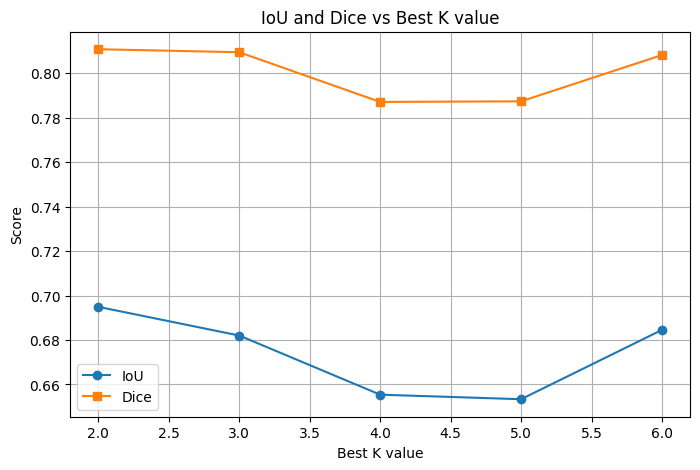

In [ ]:

metrics_with_k = []
for (ip, mp) in val_pairs:
    pred_mask, chosen_k = seg_predict_for_image_best_k(ip, gt_mask_path=mp, k_values=[2,3,4,5,6])

    if pred_mask is None:
        continue

    gt_mask = (np.load(mp)>0).astype(int)
    ys,xs = np.where(gt_mask>0)
    y1,y2,x1,x2 = ys.min(), ys.max(), xs.min(), xs.max()
    gt_crop = gt_mask[y1:y2+1, x1:x2+1].ravel()
    pr_crop = pred_mask[y1:y2+1, x1:x2+1].ravel()


    iou  = jaccard_score(gt_crop, pr_crop, zero_division=0)
    dice = f1_score(gt_crop, pr_crop, zero_division=0)
    prec = precision_score(gt_crop, pr_crop, zero_division=0)
    rec  = recall_score(gt_crop, pr_crop, zero_division=0)
    acc  = accuracy_score(gt_crop, pr_crop)

    image_metrics = {"IoU": iou, "Dice": dice, "Prec": prec, "Rec": rec, "Acc": acc, "BestK": chosen_k}
    metrics_with_k.append(image_metrics)


df_metrics = pd.DataFrame(metrics_with_k)

grouped = df_metrics.groupby("BestK")[["IoU", "Dice"]].mean().reset_index()

print("\nMean IoU and Dice per Best K:")
print(grouped)

plt.figure(figsize=(8,5))
plt.plot(grouped["BestK"], grouped["IoU"], marker="o", label="IoU")
plt.plot(grouped["BestK"], grouped["Dice"], marker="s", label="Dice")
plt.xlabel("Best K value")
plt.ylabel("Score")
plt.title("IoU and Dice vs Best K value")
plt.legend()
plt.grid(True)
plt.show()